# Final Summary

This notebook summarizes each part of the DESI Crossmatch Project:
- The HATSification of the DESI DR1 Main Dark catalog
- Each of the crossmatches performed with the HATSified DESI catalog:
  - DESI x Gaia
  - DESI x LSST DP1 object
  - DESI x LSST DP2 dia_object
  - DESI (DR1) x DESI Legacy
  - DESI x LSST DP2 object
  - DESI x LSST DP2 dia_object

We summarize key metrics, including match counts, size on disk, partitions, and approximate coverate of sky.

In addition, we plot the magnitude distribution of the DESI x LSST DP2 object crossmatch, to confirm the overall quality of the matches. 

## 1. HATSifying the DESI DR1 Main Dark catalog

Initial DESI Main Dark catalog:
- Stored in a series of FITS files, organized in directory trees based on healpix groups
- Approx XX files
- Approx XX GiB

The total wall time taken to convert the catalog to HATS format was: **64m 26s**

HATS-format DESI Main Dark catalog:
| Catalog | Row Count | Size on Disk | Partitions | Approx. Coverage | Location |
|---------|-------------|--------------|------------|------------------|----------|
| DESI DR1 Main Dark catalog | 12_778_525 | 700GiB | 5_769 | 33.39% | `/global/cfs/cdirs/cosmo/www/users/olynn/` |


In [9]:
import hats

desi_cat = hats.read_hats("https://portal.nersc.gov/project/cosmo/users/olynn/desi-dr1-main-dark/")
desi_cat.aggregate_column_statistics()

,min_value,max_value,null_count,row_count
column_names,,,,
TARGETID,-1.195895e+08,2.882316e+18,0,12778525
TARGET_RA,6.814053e-05,3.600000e+02,0,12778525
TARGET_DEC,-1.944925e+01,7.911097e+01,0,12778525
Z,-4.312426e-03,6.983504e+00,0,12778525
ZERR,2.232146e-46,1.981257e-02,0,12778525
spectra_b.wavelength,3.600000e+03,5.800000e+03,0,35153722275
spectra_b.flux,-8.788638e+03,6.976088e+04,0,35153722275
spectra_b.ivar,-0.000000e+00,6.922378e+01,0,35153722275
spectra_b.mask,0.000000e+00,1.025000e+03,0,35153722275


## 2. Crossmatch Results

### 2.2 Summary Table

| Catalog | Match Count | Size on Disk | Partitions | Approx. Coverage | Location |
|---------|-------------|--------------|------------|------------------|----------|
| DESI x Gaia | 965_083 | 71 GiB | 5_764 | 33.38% | `/global/cfs/cdirs/cosmo/users/olynn/` |
| DESI × LSST DP1 object | 6_141 | 534 MiB | 60 | 0.01 % | `/global/cfs/cdirs/cosmo/users/olynn/` |
| DESI × LSST DP1 dia_object | 293 | 27 MiB | 7 | 0.01 % | `/global/cfs/cdirs/cosmo/users/olynn/` |
| DESI DR1 × DESI Legacy | 9_198_171 | 561 GiB | 19_221 | 21.77% | `/global/cfs/cdirs/cosmo/users/olynn/` |
| DESI × LSST DP2 object | 1_127_685 | 7.3 GiB | 2_125 | 3.85% | `/sdf/data/rubin/user/olynn` |
| DESI × LSST DP2 dia_object | 82_279 | 94 GiB | 24_553 | 3.57% | `/sdf/data/rubin/user/olynn` |


### 2.2 Deeper Dive: DESI × LSST DP2 object

This is Notebook 5.0 in the project repository.

- Survey combination: DESI Main Survey DR1 dark program × LSST DP2
- Match count: **1.1 million**

This final crossmatch assesses the DESI footprint against the newer LSST DP2 dataset. The accompanying magnitude distribution provides a rapid quantitative check on whether the matches are dominated by expected bright sources or by potentially low-quality detections.


In [ ]:
import logging
import warnings
from pathlib import Path

import lsdb
import matplotlib.pyplot as plt
import pandas as pd
from dask.distributed import Client


# Make a dask client and supress cluttered warnings.
client = Client(n_workers=16, memory_limit="20GB", local_directory=Path("/sdf/data/rubin/user/olynn/tmp"))
warnings.filterwarnings("ignore", module="distributed.*")
logging.getLogger("distributed.scheduler").setLevel(logging.ERROR)
logging.getLogger("distributed.node").setLevel(logging.ERROR)

# Get the catalog.
catalog_path = "/sdf/data/rubin/user/olynn/desi_x_lsst_dp2_object"
catalog = lsdb.open_catalog(catalog_path)

Our call to aggregate_column_statistics() in notebook 5.0 showed us:

| Column Name | min_value | max_value | null_count | row_count |
|-------------|-----------|-----------|------------|-----------|
| r_psfMag | 1.488846e+01 | 8.192420e+01 | 200_073 | 1_127_685 |

Let's use width-1 bins across this range (14, 82)

In [ ]:
# Define the magnitude bins for the histogram. Here, we are creating bins from 14 to 81 with a width of 1.

mag_bins = np.arange(14, 82, 1)

def observation_histogram(df):
    df["binned"] = pd.cut(df["r_psfMag"], bins=mag_bins) # creates a new column "binned" with the bin labels for each observation
    binned_data = df.groupby("binned", observed=True)["r_psfMag"].count()  # groups the data by the "binned" column and counts the number of observations in each bin
    return pd.DataFrame(binned_data)

result = catalog.map_partitions(observation_histogram).compute()

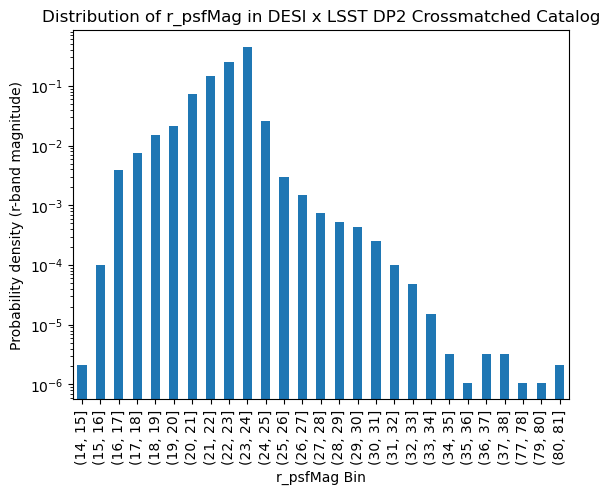

In [ ]:
# Plot the histogram of the binned data, normalized to show the probability density.
# Note the y-axis is on a log scale.

total_histogram = result.groupby("binned", observed=True).sum()
(total_histogram / total_histogram.sum()).plot(kind="bar")

plt.title("Distribution of r_psfMag in DESI x LSST DP2 Crossmatched Catalog")
plt.xlabel("r_psfMag Bin")
plt.ylabel("Probability density (r-band magnitude)")
plt.legend().set_visible(False)
plt.yscale("log")

plt.show()